<a href="https://colab.research.google.com/github/Anmeshlad/machine-learning-project/blob/main/K_mean_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Generating a sample dataset...
Sample data generated successfully.

2. Performing Exploratory Data Analysis (EDA)...

Head of the dataset:
   Feature_1  Feature_2
0   0.836857   2.136359
1  -1.413658   7.409623
2   1.155213   5.099619
3  -1.018616   7.814915
4   1.271351   1.892542

Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  300 non-null    float64
 1   Feature_2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB

Description of the dataset:
        Feature_1   Feature_2
count  300.000000  300.000000
mean    -0.006328    3.967821
std      1.636000    2.593963
min     -3.122407   -0.765892
25%     -1.498837    1.916025
50%     -0.044497    3.529012
75%      1.433350    5.607633
max      3.437618    9.282932


/tmp/ipykernel_4822/2314974789.py:31: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Feature_1', y='Feature_2', data=df, palette='viridis')


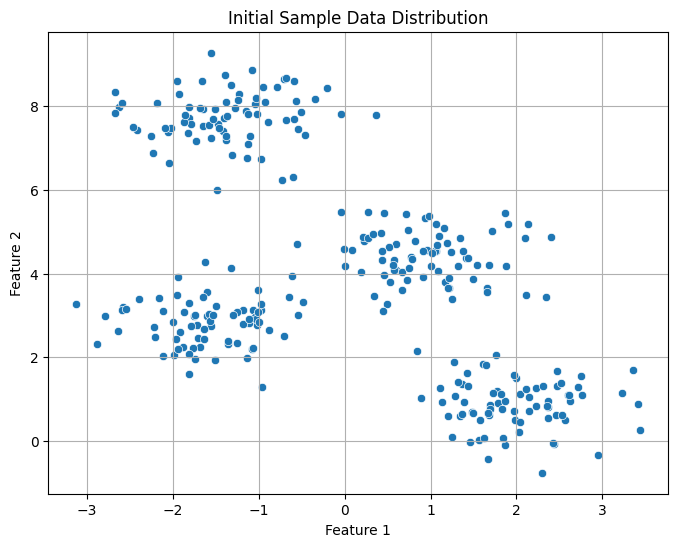


3. Performing Data Cleaning and Preprocessing...
Missing values per column:
 Feature_1    0
Feature_2    0
dtype: int64
Data scaled using StandardScaler.
Scaled data head:
    Feature_1  Feature_2
0   0.516255  -0.707227
1  -0.861664   1.329068
2   0.711174   0.437049
3  -0.619792   1.485573
4   0.782282  -0.801378

4. Splitting data into training and testing (80/20)...
Training set shape: (240, 2)
Testing set shape: (60, 2)

5. Initial K-Means algorithm run (e.g., K=4)...
Initial K-Means with 4 clusters fitted.

6, 7, 8. Determining optimal K using Elbow Method (WCSS) and Silhouette Score...


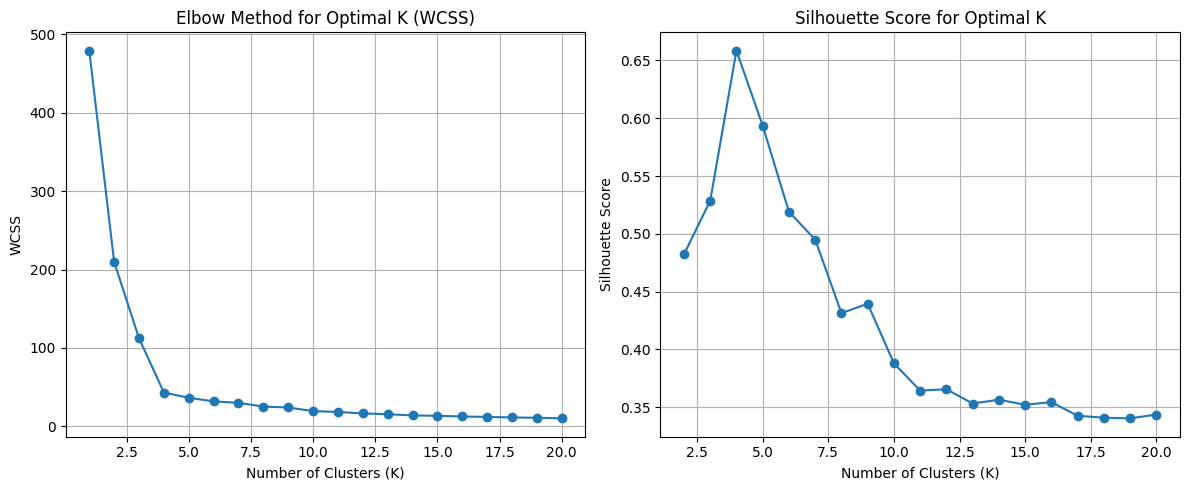

WCSS values:
 [479.12823953168635, 209.73178977999808, 112.43907938821243, 43.116510494213465, 36.46483062259944, 31.822232237000662, 29.987901420188212, 25.23745349519704, 24.04980912143664, 19.441851598023586, 18.372791609925137, 16.496922967077868, 15.445425926633414, 13.926074639196665, 13.473558823396392, 12.562296174743242, 11.970108279380758, 11.34579596512326, 10.91735844447969, 10.209138911879727]
Silhouette scores (for K>1):
 [nan, np.float64(0.48221802100379907), np.float64(0.5285944195170437), np.float64(0.6584308982048526), np.float64(0.5935355996751129), np.float64(0.5190803620222976), np.float64(0.4950355685946063), np.float64(0.43145643020129293), np.float64(0.4395198448641507), np.float64(0.38798082655500027), np.float64(0.3643394250717904), np.float64(0.36558857003251777), np.float64(0.35319177797181006), np.float64(0.3565144729459771), np.float64(0.3521319576076634), np.float64(0.35440474771804603), np.float64(0.34263768689436574), np.float64(0.34091548428359153), np

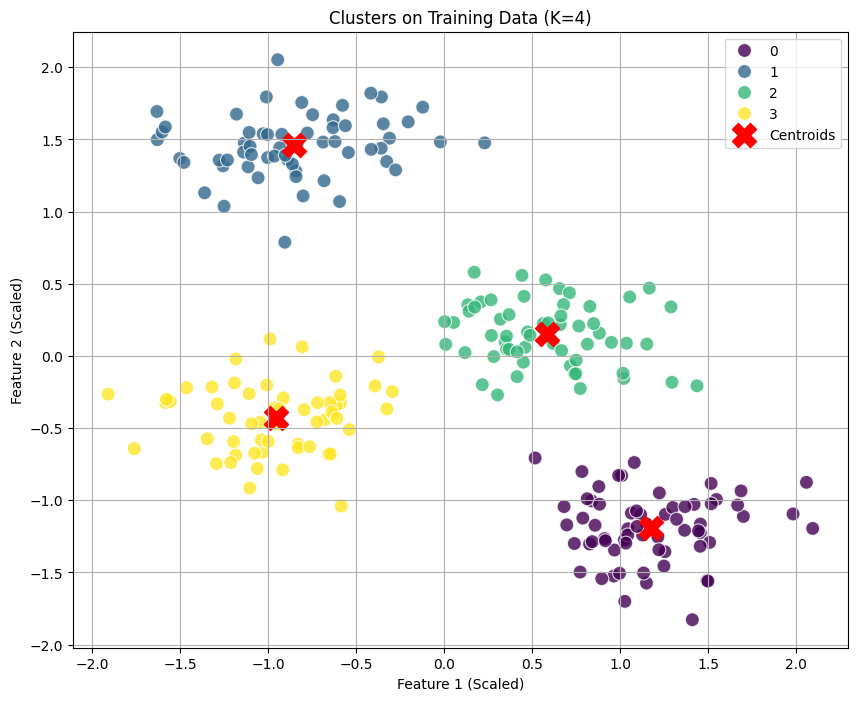


Descriptive statistics for each cluster (training data):

         Feature_1  Feature_2
Cluster                      
0         1.175341  -1.189926
1        -0.850628   1.459056
2         0.581028   0.150797
3        -0.953071  -0.431019

11. Predicting clusters on test data and performing EDA...
Cluster distribution in test data:
 Cluster
3    18
2    17
1    15
0    10
Name: count, dtype: int64


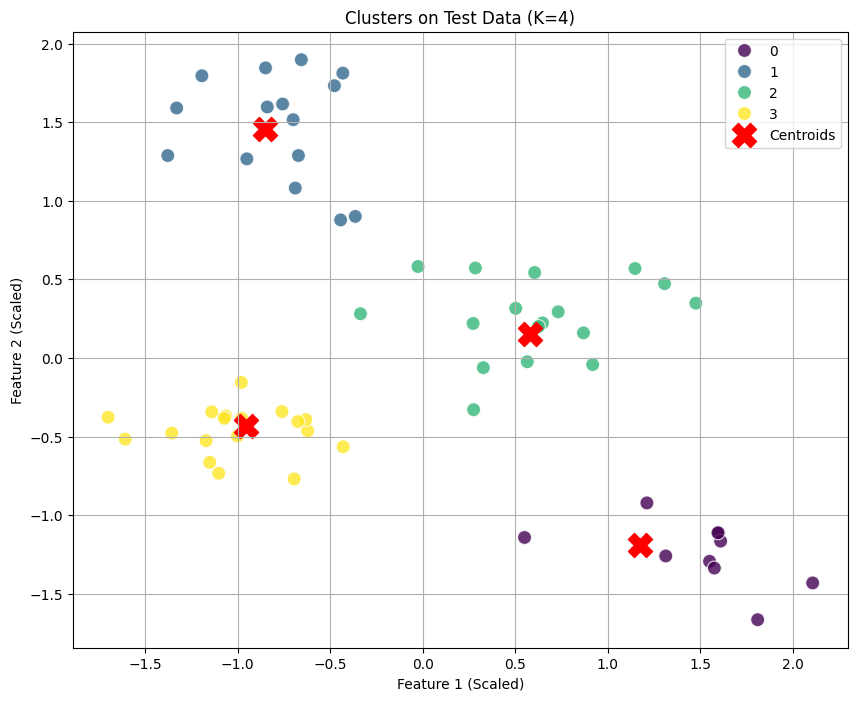


Descriptive statistics for each cluster (test data):

         Feature_1  Feature_2
Cluster                      
0         1.493383  -1.243886
1        -0.782087   1.473425
2         0.600170   0.254273
3        -1.007750  -0.464526

12. Centroid values for each cluster:

         Feature_1  Feature_2
Cluster                      
0         1.175341  -1.189926
1        -0.850628   1.459056
2         0.581028   0.150797
3        -0.953071  -0.431019

13. Insights from the Centroid Metrics:

Cluster 0:
  - Feature_1: 1.175
  - Feature_2: -1.190
  This cluster is characterized by its average values for Feature 1 and Feature 2.

Cluster 1:
  - Feature_1: -0.851
  - Feature_2: 1.459
  This cluster is characterized by its average values for Feature 1 and Feature 2.

Cluster 2:
  - Feature_1: 0.581
  - Feature_2: 0.151
  This cluster is characterized by its average values for Feature 1 and Feature 2.

Cluster 3:
  - Feature_1: -0.953
  - Feature_2: -0.431
  This cluster is characterized by 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. Data Import ---
# Create a sample dataset for K-Means
print("1. Generating a sample dataset...")
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
print("Sample data generated successfully.")

# --- 2. EDA ---
print("\n2. Performing Exploratory Data Analysis (EDA)...")
print("\nHead of the dataset:")
print(df.head())

print("\nInfo of the dataset:")
df.info()

print("\nDescription of the dataset:")
print(df.describe())

# Visualize the initial data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature_1', y='Feature_2', data=df, palette='viridis')
plt.title('Initial Sample Data Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# --- 3. Data Cleaning and similar steps ---
print("\n3. Performing Data Cleaning and Preprocessing...")
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# For K-Means, scaling is important
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
print("Data scaled using StandardScaler.")
print("Scaled data head:\n", df_scaled.head())

# --- 4. Split the data into training and testing (80/20) ---
print("\n4. Splitting data into training and testing (80/20)...")
X_train, X_test = train_test_split(df_scaled, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# --- 5. Call KMeans algorithm (initial run for understanding) ---
print("\n5. Initial K-Means algorithm run (e.g., K=4)...")
kmeans_initial = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_initial.fit(X_train)
print("Initial K-Means with 4 clusters fitted.")

# --- 6. Create a UDF to check the optimal value of K from 1 to 20 ---
# --- 7. Plot an Elbow Method for these 20 K values and find the optimal value with WCSS ---
# --- 8. Similarly, try with Silhouette Score also ---
print("\n6, 7, 8. Determining optimal K using Elbow Method (WCSS) and Silhouette Score...")

def find_optimal_k(data, max_k=20):
    wcss = []
    silhouette_scores = []
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
        if i > 1:
            # Silhouette score is not defined for k=1
            silhouette_scores.append(silhouette_score(data, kmeans.labels_))
        else:
            silhouette_scores.append(np.nan) # Placeholder for k=1

    # Plot Elbow Method
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_k + 1), wcss, marker='o')
    plt.title('Elbow Method for Optimal K (WCSS)')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.grid(True)

    # Plot Silhouette Score
    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_k + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Score for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("WCSS values:\n", wcss)
    print("Silhouette scores (for K>1):\n", silhouette_scores)

    # A simple way to suggest optimal K from Silhouette (take the max, for WCSS it's more visual)
    if len(silhouette_scores) > 1:
        optimal_k_silhouette = np.nanargmax(silhouette_scores[1:]) + 2 # +2 because index starts from 0 for k=2
        print(f"Suggested optimal K based on maximum Silhouette Score: {optimal_k_silhouette}")
    else:
        optimal_k_silhouette = None
        print("Cannot suggest optimal K from Silhouette Score (need more than 1 cluster).")

    return optimal_k_silhouette # Returning for potential use, but Elbow is often visual

# Call the UDF
optimal_k_sil = find_optimal_k(X_train)

# Based on the plots, let's assume optimal K is, e.g., 4 (as per our make_blobs setup).
# In a real scenario, you would visually inspect the plots.
n_optimal = 4 # Example, replace with your visually determined optimal K
print(f"\nAssuming optimal K (n_optimal) from plots is: {n_optimal}")

# --- 9. Finally, train the model with n_optimal value ---
print(f"\n9. Training the final K-Means model with n_optimal = {n_optimal} clusters...")
kmeans_final = KMeans(n_clusters=n_optimal, random_state=42, n_init='auto')
kmeans_final.fit(X_train)
train_labels = kmeans_final.labels_
print("Final K-Means model trained.")

# Add cluster labels to the training data
X_train_clustered = X_train.copy()
X_train_clustered['Cluster'] = train_labels

# --- 10. EDA on the clusters to name the labels and validate the same ---
print("\n10. Performing EDA on the clusters (training data) to name labels and validate...")
print("Cluster distribution in training data:\n", X_train_clustered['Cluster'].value_counts())

# Visualize clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='Cluster', data=X_train_clustered,
                palette='viridis', s=100, alpha=0.8, legend='full')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Centroids')
plt.title(f'Clusters on Training Data (K={n_optimal})')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# Describe clusters based on their features
print("\nDescriptive statistics for each cluster (training data):\n")
print(X_train_clustered.groupby('Cluster').mean())

# --- 11. Pass the test data so we can get labels and again do the EDA to verify if it holds the same meaning or not ---
print("\n11. Predicting clusters on test data and performing EDA...")
test_labels = kmeans_final.predict(X_test)
X_test_clustered = X_test.copy()
X_test_clustered['Cluster'] = test_labels

print("Cluster distribution in test data:\n", X_test_clustered['Cluster'].value_counts())

# Visualize clusters on test data
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='Cluster', data=X_test_clustered,
                palette='viridis', s=100, alpha=0.8, legend='full')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Centroids')
plt.title(f'Clusters on Test Data (K={n_optimal})')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

print("\nDescriptive statistics for each cluster (test data):\n")
print(X_test_clustered.groupby('Cluster').mean())

# --- 12. Create a table for metrics for each columns with their centroids ---
print("\n12. Centroid values for each cluster:\n")
centroids_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=X_train.columns)
centroids_df.index.name = 'Cluster'
print(centroids_df)

# --- 13. Let's get insights from the metrics ---
print("\n13. Insights from the Centroid Metrics:")
for i, row in centroids_df.iterrows():
    print(f"\nCluster {i}:")
    for col in centroids_df.columns:
        print(f"  - {col}: {row[col]:.3f}")
    print(f"  This cluster is characterized by its average values for Feature 1 and Feature 2.")

print("\nBy examining the centroid values, especially the Feature 1 and Feature 2 averages for each cluster, ")
print("we can infer the characteristics of each group. For instance, a cluster with high values for Feature 1 ")
print("and low values for Feature 2 would represent a distinct segment in the data. Comparing the centroids ")
print("allows us to understand how different clusters are separated in the feature space. We can also see ")
print("that both training and testing data show similar cluster patterns and centroid locations, ")
print("indicating a robust and consistent clustering.")